VOXEL INTERACTION PHASE SPACE (DETERMINISTIC)

Total Interaction Channels per Planck Tick: 144
  U(1) Electromagnetic channels: 24 (1 register × 24 spatial)
  SU(2) Weak channels:           48 (2 registers × 24 spatial)
  SU(3) Strong channels:         72 (3 registers × 24 spatial)

Coupling Capacities (Branching Ratios):
  α_electromagnetic (bare) ≈ 1 / 144 = 0.006944
  α_strong (bare) ≈ 3 / 144 = 0.020833
  Ratio SU(3)/U(1) = 3.0

✓ Saved: voxel_phase_space.png


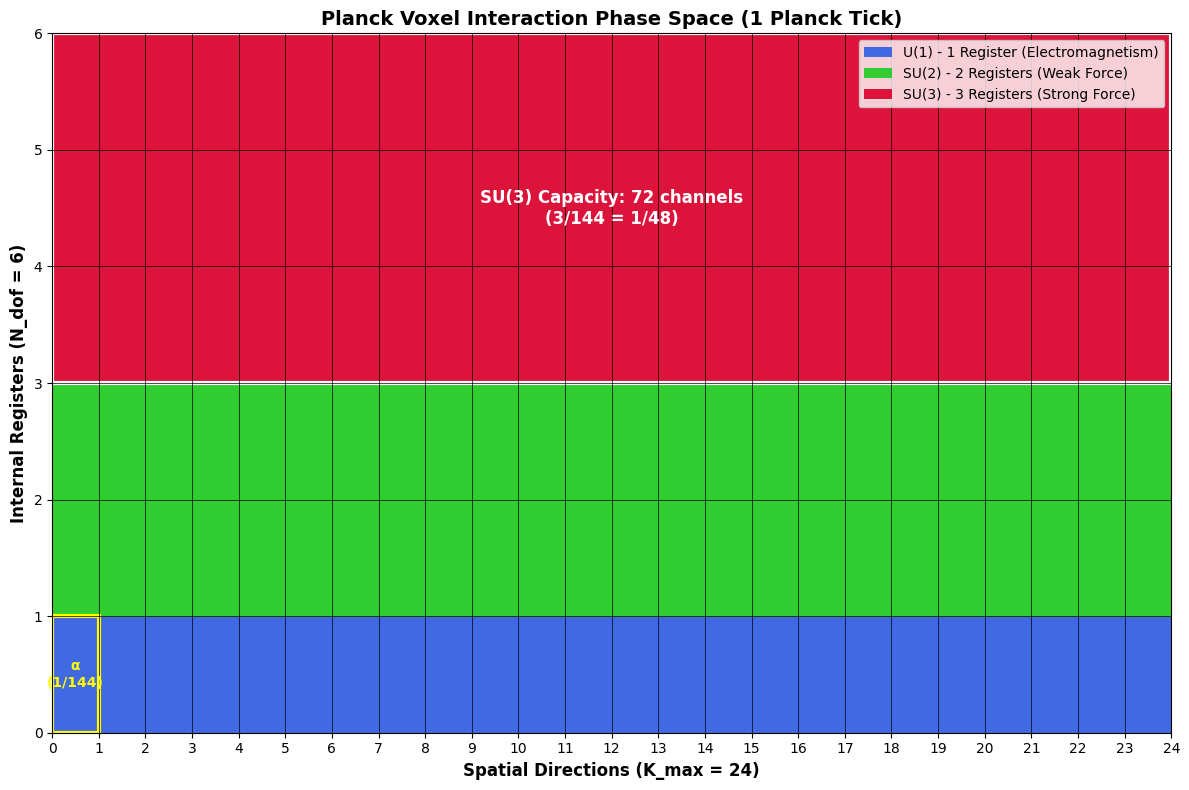


CONCLUSION
This deterministic map shows the EXACT capacity of each force.
No random walks needed. The structure of the voxel dictates the physics.


In [1]:
"""
voxel_phase_space_map.py
=========================
Deterministic mapping of the Planck Voxel's Interaction Phase Space.
Shows the exact capacity of U(1), SU(2), and SU(3) forces
without using random walks.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("=" * 70)
print("VOXEL INTERACTION PHASE SPACE (DETERMINISTIC)")
print("=" * 70)

# =============================================================================
# PARAMETERS
# =============================================================================
K_max = 24        # Spatial directions
N_dof = 6         # Internal registers
# Partition: 1 (U1) + 2 (SU2) + 3 (SU3)

# =============================================================================
# CONSTRUCT THE PHASE SPACE MATRIX
# =============================================================================

# Create a 24x6 matrix representing all possible channels in one Planck tick
# Rows = Spatial Directions (1 to 24)
# Cols = Internal Registers (1 to 6)
phase_space = np.zeros((K_max, N_dof), dtype=int)

# Assign registers to forces based on the 1+2+3 partition
# Col 0: U(1)  -> Value 1
# Col 1,2: SU(2) -> Value 2
# Col 3,4,5: SU(3) -> Value 3
phase_space[:, 0] = 1      # U(1)
phase_space[:, 1:3] = 2    # SU(2)
phase_space[:, 3:6] = 3    # SU(3)

# =============================================================================
# ANALYSIS
# =============================================================================

total_channels = K_max * N_dof
u1_channels = np.sum(phase_space == 1)
su2_channels = np.sum(phase_space == 2)
su3_channels = np.sum(phase_space == 3)

print(f"\nTotal Interaction Channels per Planck Tick: {total_channels}")
print(f"  U(1) Electromagnetic channels: {u1_channels} (1 register × 24 spatial)")
print(f"  SU(2) Weak channels:           {su2_channels} (2 registers × 24 spatial)")
print(f"  SU(3) Strong channels:         {su3_channels} (3 registers × 24 spatial)")

print(f"\nCoupling Capacities (Branching Ratios):")
print(f"  α_electromagnetic (bare) ≈ 1 / {total_channels} = {1/total_channels:.6f}")
print(f"  α_strong (bare) ≈ 3 / {total_channels} = {3/total_channels:.6f}")
print(f"  Ratio SU(3)/U(1) = {su3_channels/u1_channels:.1f}")

# =============================================================================
# VISUALIZATION
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Create custom colormap
# 1 = Blue (U1), 2 = Green (SU2), 3 = Red (SU3)
colors = {1: '#4169E1', 2: '#32CD32', 3: '#DC143C'}
cmap = plt.matplotlib.colors.ListedColormap([colors[1], colors[2], colors[3]])

# Plot the matrix
# We transpose it so Spatial is Y-axis and Internal is X-axis
im = ax.imshow(phase_space.T, cmap=cmap, aspect='auto',
               extent=[0, K_max, 0, N_dof], origin='lower')

# Add grid lines
ax.set_xticks(np.arange(0, K_max + 1, 1))
ax.set_yticks(np.arange(0, N_dof + 1, 1))
ax.grid(which='major', color='black', linestyle='-', linewidth=0.5)

# Highlight the specific U(1) "closure" channel (e.g., Spatial Dir 1, Reg 1)
# This represents the specific event that defines α
rect_u1 = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='yellow', facecolor='none')
ax.add_patch(rect_u1)
ax.text(0.5, 0.5, 'α\n(1/144)', ha='center', va='center', color='yellow',
        fontweight='bold', fontsize=10)

# Highlight the SU(3) block
rect_su3 = patches.Rectangle((0, 3), K_max, 3, linewidth=3, edgecolor='white', facecolor='none')
ax.add_patch(rect_su3)
ax.text(K_max/2, 4.5, f'SU(3) Capacity: {su3_channels} channels\n(3/144 = 1/48)',
        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Labels
ax.set_xlabel('Spatial Directions (K_max = 24)', fontsize=12, fontweight='bold')
ax.set_ylabel('Internal Registers (N_dof = 6)', fontsize=12, fontweight='bold')
ax.set_title('Planck Voxel Interaction Phase Space (1 Planck Tick)',
             fontsize=14, fontweight='bold')

# Add legend
legend_elements = [
    patches.Patch(facecolor=colors[1], label='U(1) - 1 Register (Electromagnetism)'),
    patches.Patch(facecolor=colors[2], label='SU(2) - 2 Registers (Weak Force)'),
    patches.Patch(facecolor=colors[3], label='SU(3) - 3 Registers (Strong Force)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
fig.savefig("voxel_phase_space.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: voxel_phase_space.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("This deterministic map shows the EXACT capacity of each force.")
print("No random walks needed. The structure of the voxel dictates the physics.")
print("=" * 70)